In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from torch import nn
from torch.utils.data import Dataset, DataLoader

In [3]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("wordnet")
nltk.download("stopwords")


import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Pavithran\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Pavithran\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Pavithran\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Pavithran\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# 1. Data Exploration & Preprocessing

## TRAIN DATASET

In [4]:
TRAIN_PATH = "..\\data\\train.csv"
df = pd.read_csv(TRAIN_PATH)

print("Shape:", df.shape)
print("\nColumns :\n", df.columns)
print("\nColumn dtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (159571, 8)

Columns :
 Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='str')

Column dtypes:
 id                 str
comment_text       str
toxic            int64
severe_toxic     int64
obscene          int64
threat           int64
insult           int64
identity_hate    int64
dtype: object

Missing values:
 id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

Duplicate rows: 0


In [5]:
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [6]:
df["toxic"].value_counts()

toxic
0    144277
1     15294
Name: count, dtype: int64

In [7]:
df["toxic"].value_counts(normalize=True) * 100

toxic
0    90.415552
1     9.584448
Name: proportion, dtype: float64

## TEST DATASET

In [8]:
TEST_PATH = "..\\data\\test.csv" 
df_test = pd.read_csv(TEST_PATH)

print("Shape:", df_test.shape)
print("\nColumns :\n", df_test.columns)
print("\nColumn dtypes:\n", df_test.dtypes)
print("\nMissing values:\n", df_test.isnull().sum())
print("\nDuplicate rows:", df_test.duplicated().sum())

Shape: (153164, 2)

Columns :
 Index(['id', 'comment_text'], dtype='str')

Column dtypes:
 id              str
comment_text    str
dtype: object

Missing values:
 id              0
comment_text    0
dtype: int64

Duplicate rows: 0


In [9]:
df_test.head()

,id,comment_text
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap..."
3,00017563c3f7919a,":If you have a look back at the source, the in..."
4,00017695ad8997eb,I don't anonymously edit articles at all.


## Toxicity column distribution

In [10]:
toxicity_cols = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

label_counts = df[toxicity_cols].sum().sort_values(ascending=False)
label_summary = pd.DataFrame({
    'Count': label_counts,
    'Percentage': (label_counts / len(df) * 100).round(2)
})
print(label_summary)

               Count  Percentage
toxic          15294        9.58
obscene         8449        5.29
insult          7877        4.94
severe_toxic    1595        1.00
identity_hate   1405        0.88
threat           478        0.30


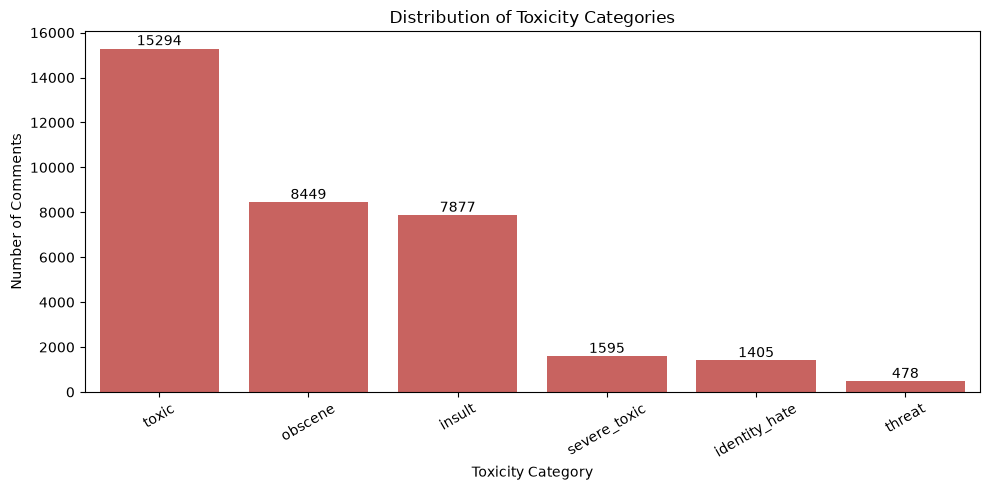

In [11]:
plt.figure(figsize=(10,5))
ax = sns.barplot(x=label_counts.index, y=label_counts.values, color='#d9534f')
plt.title('Distribution of Toxicity Categories')
plt.xlabel('Toxicity Category')
plt.ylabel('Number of Comments')
plt.xticks(rotation=30)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')
plt.tight_layout()
plt.show()

## Create binary target 

A comment is considered toxic when **at least one** of the six toxicity labels is 1.

In [12]:
df['is_toxic'] = df[toxicity_cols].max(axis=1)

binary_summary = df['is_toxic'].value_counts().sort_index().to_frame('Count')
binary_summary['Percentage'] = (binary_summary['Count'] / len(df) * 100).round(2)
binary_summary.index = ['Non-Toxic', 'Toxic']
print(binary_summary)

            Count  Percentage
Non-Toxic  143346       89.83
Toxic       16225       10.17


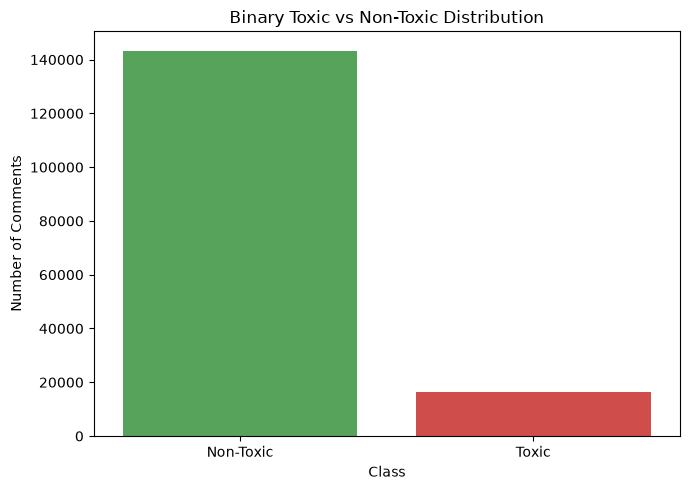

In [13]:
plt.figure(figsize=(7,5))
sns.countplot(x=df['is_toxic'].map({0:'Non-Toxic',1:'Toxic'}), palette=['#4CAF50','#E53935'],hue=df['is_toxic'].map({0:'Non-Toxic',1:'Toxic'}))
plt.title('Binary Toxic vs Non-Toxic Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Comments')
plt.tight_layout()
plt.show()

## Text Cleaning

In [14]:
def get_clean_text(text):

    text = str(text).lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+", " ", text)

    # Remove mentions
    text = re.sub(r"@\w+", " ", text)

    # Remove # symbol but retain the hashtag word
    text = re.sub(r"#(\w+)", r"\1", text)

    # Remove numbers
    text = re.sub(r"\d+", " ", text)

    # Keep only alphabets and spaces
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenization
    tokens = word_tokenize(text)
    
    # Lemmatization
    lemmatizer = WordNetLemmatizer()

    cleaned_tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
    ]

    if not cleaned_tokens:
        return "emptycomment"

    return " ".join(cleaned_tokens)

In [15]:
df["clean_comments"] = df["comment_text"].apply(get_clean_text)

In [16]:
df[["comment_text", "clean_comments"]].head(10)

,comment_text,clean_comments
0,Explanation\nWhy the edits made under my usern...,explanation why the edits made under my userna...
1,D'aww! He matches this background colour I'm s...,d aww he match this background colour i m seem...
2,"Hey man, I'm really not trying to edit war. It...",hey man i m really not trying to edit war it s...
3,"""\nMore\nI can't make any real suggestions on ...",more i can t make any real suggestion on impro...
4,"You, sir, are my hero. Any chance you remember...",you sir are my hero any chance you remember wh...
5,"""\n\nCongratulations from me as well, use the ...",congratulation from me a well use the tool wel...
6,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,cocksucker before you piss around on my work
7,Your vandalism to the Matt Shirvington article...,your vandalism to the matt shirvington article...
8,Sorry if the word 'nonsense' was offensive to ...,sorry if the word nonsense wa offensive to you...
9,alignment on this subject and which are contra...,alignment on this subject and which are contra...


## Split training data

In [17]:
X = df["clean_comments"]
y = df["is_toxic"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Create Vocabulary

In [18]:
vocab = set()

for comment in X_train:

    for word in comment.split():

        vocab.add(word)

vocab = sorted(vocab)

word2idx = {
    word: idx + 2
    for idx, word in enumerate(vocab)
}

word2idx["<PAD>"] = 0
word2idx["<UNK>"] = 1

## Convert text into integer

In [19]:
def encode_text(text, word2idx):

    encoded = []

    for word in text.split():

        index = word2idx.get(
            word,
            word2idx["<UNK>"]
        )

        encoded.append(index)

    return encoded

In [20]:
X_train_encoded = [
    encode_text(text, word2idx)
    for text in X_train
]

X_val_encoded = [
    encode_text(text, word2idx)
    for text in X_val
]

In [21]:
sequence_lengths = [
    len(seq)
    for seq in X_train_encoded
]

print(pd.Series(sequence_lengths).describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
))

MAX_LEN = int(
    np.percentile(
        sequence_lengths, 95
    )
)

print("MAX_LEN (95th percentile):", MAX_LEN)

count    127656.000000
mean         67.575813
std         100.040620
min           1.000000
50%          36.000000
75%          76.000000
90%         153.000000
95%         231.000000
99%         572.000000
max        1403.000000
dtype: float64
MAX_LEN (95th percentile): 231


## Padding and Truncation

In [22]:
def pad_sequence(sequence, max_len=MAX_LEN):

    # Truncate long sequences
    if len(sequence) > max_len:
        sequence = sequence[:max_len]

    # Pad short sequences
    else:
        sequence = sequence + [0] * (max_len - len(sequence))

    return sequence

In [23]:
X_train_padded = [
    pad_sequence(seq)
    for seq in X_train_encoded
]

X_val_padded = [
    pad_sequence(seq)
    for seq in X_val_encoded
]

## Convert to pytorch tensor

In [24]:
X_train_tensor = torch.tensor(
    X_train_padded,
    dtype=torch.long
)

X_val_tensor = torch.tensor(
    X_val_padded,
    dtype=torch.long
)

y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val.values,
    dtype=torch.float32
)

In [25]:
print(X_train_tensor.shape)
print(y_train_tensor.shape)

print(X_val_tensor.shape)
print(y_val_tensor.shape)

torch.Size([127656, 231])
torch.Size([127656])
torch.Size([31915, 231])
torch.Size([31915])


## Create pytorch dataset

In [26]:
class ToxicityDataset(Dataset):

    def __init__(self, X, y):

        self.X = X
        self.y = y

    def __len__(self):

        return len(self.X)

    def __getitem__(self, index):

        return self.X[index], self.y[index]

train_dataset = ToxicityDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = ToxicityDataset(
    X_val_tensor,
    y_val_tensor
)

## Create DataLoaders

In [27]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [28]:

class ToxicityLSTM(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_dim=64,
        num_layers=1,
        dropout=0.5
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(
            hidden_dim,
            1
        )

    def forward(self, x):

        # Convert word IDs into embeddings
        embedded = self.embedding(x)

        # Pass embeddings through LSTM
        output, (hidden, cell) = self.lstm(embedded)

        # Take final hidden state
        last_hidden = hidden[-1]

        # Apply dropout
        last_hidden = self.dropout(last_hidden)

        # Fully connected layer
        output = self.fc(last_hidden)

        return output.squeeze(1)

In [29]:
vocab_size = len(word2idx)

print("Vocabulary size:", vocab_size)

model = ToxicityLSTM(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_dim=64,
    num_layers=1,
    dropout=0.5
)

Vocabulary size: 135759


In [30]:
print(model)

ToxicityLSTM(
  (embedding): Embedding(135759, 128, padding_idx=0)
  (lstm): LSTM(128, 64, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


## Choose device

In [31]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using:", device)

model = model.to(device)

Using: cpu


In [32]:
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
print("pos_weight:", pos_weight.item())

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

pos_weight: 8.834822654724121


## Model Training and Evaluation

In [33]:
def evaluate_model(model, data_loader, criterion, device):

    model.eval()

    total_loss = 0

    all_predictions = []
    all_probabilities = []
    all_labels = []

    with torch.no_grad():

        for X_batch, y_batch in data_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            total_loss += loss.item()

            probabilities = torch.sigmoid(outputs)

            predictions = (probabilities >= 0.5).float()

            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(data_loader)

    accuracy = accuracy_score(all_labels, all_predictions)
    precision = precision_score(all_labels, all_predictions, zero_division=0)
    recall = recall_score(all_labels, all_predictions, zero_division=0)
    f1 = f1_score(all_labels, all_predictions, zero_division=0)
    roc_auc = roc_auc_score(all_labels, all_probabilities)

    return avg_loss, accuracy, precision, recall, f1, roc_auc

In [34]:
EPOCHS = 5

history = []  

for epoch in range(EPOCHS):

    model.train()

    total_train_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(X_batch)

        # Calculate loss
        loss = criterion(outputs, y_batch)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    val_loss, accuracy, precision, recall, f1, roc_auc = evaluate_model(
        model, val_loader, criterion, device
    )
    history.append({
        "epoch": epoch + 1,
        "train_loss": avg_train_loss,
        "val_loss": val_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
    })

    print(
        f"Epoch {epoch+1}/{EPOCHS} "
        f"| Train Loss: {avg_train_loss:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Accuracy: {accuracy:.4f} "
        f"| Precision: {precision:.4f} "
        f"| Recall: {recall:.4f} "
        f"| F1: {f1:.4f} "
        f"| ROC-AUC: {roc_auc:.4f}"
    )

Epoch 1/5 | Train Loss: 1.1615 | Val Loss: 1.1177 | Accuracy: 0.8837 | Precision: 0.4138 | Recall: 0.3464 | F1: 0.3771 | ROC-AUC: 0.6494
Epoch 2/5 | Train Loss: 1.0864 | Val Loss: 1.0875 | Accuracy: 0.8905 | Precision: 0.4532 | Recall: 0.3744 | F1: 0.4101 | ROC-AUC: 0.6975
Epoch 3/5 | Train Loss: 1.0374 | Val Loss: 0.9858 | Accuracy: 0.8359 | Precision: 0.3404 | Recall: 0.6552 | F1: 0.4481 | ROC-AUC: 0.7975
Epoch 4/5 | Train Loss: 0.9482 | Val Loss: 0.8582 | Accuracy: 0.7914 | Precision: 0.3040 | Recall: 0.8157 | F1: 0.4430 | ROC-AUC: 0.8371
Epoch 5/5 | Train Loss: 0.7997 | Val Loss: 0.7512 | Accuracy: 0.8517 | Precision: 0.3895 | Recall: 0.8086 | F1: 0.5257 | ROC-AUC: 0.8734


   epoch  train_loss  val_loss  accuracy  precision    recall        f1  \
0      1    1.161535  1.117744  0.883660   0.413844  0.346379  0.377118   
1      2    1.086361  1.087525  0.890459   0.453189  0.374422  0.410057   
2      3    1.037446  0.985761  0.835877   0.340432  0.655162  0.448051   
3      4    0.948237  0.858163  0.791415   0.304043  0.815716  0.442975   
4      5    0.799674  0.751209  0.851668   0.389491  0.808629  0.525746   

    roc_auc  
0  0.649363  
1  0.697493  
2  0.797470  
3  0.837121  
4  0.873412  


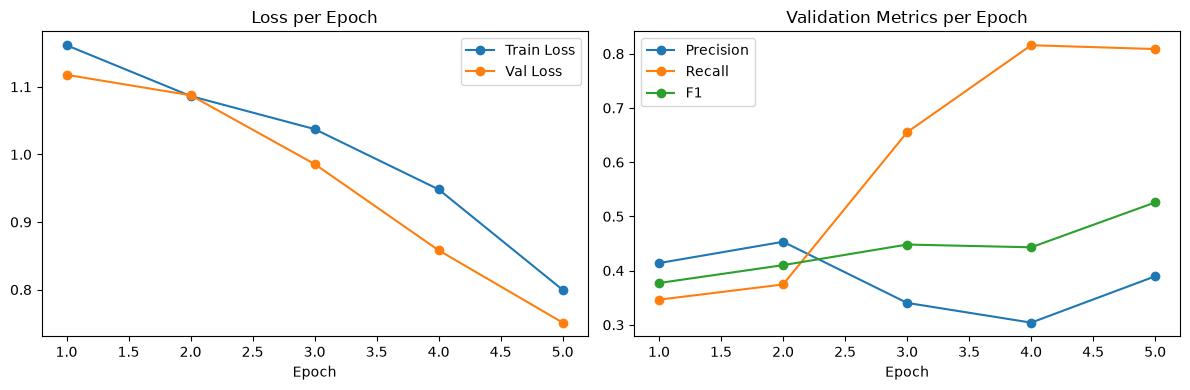

In [35]:
hist_df = pd.DataFrame(history)
print(hist_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_df['epoch'], hist_df['train_loss'], marker='o', label='Train Loss')
axes[0].plot(hist_df['epoch'], hist_df['val_loss'], marker='o', label='Val Loss')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(hist_df['epoch'], hist_df['precision'], marker='o', label='Precision')
axes[1].plot(hist_df['epoch'], hist_df['recall'], marker='o', label='Recall')
axes[1].plot(hist_df['epoch'], hist_df['f1'], marker='o', label='F1')
axes[1].set_title('Validation Metrics per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

# 2. Experimenting with Alternative Architectures (RNN & BERT)

The assignment asks us to experiment with LSTMs, RNNs, and transformer-based models (BERT). The LSTM above is the primary model. Below: a lighter vanilla RNN trained the same way for direct comparison, and a BERT fine-tuning reference implementation.

## 2.1 Vanilla RNN (comparison model)

In [36]:
class ToxicityRNN(nn.Module):
    """Same shape as ToxicityLSTM but uses a vanilla nn.RNN — faster to train,
    but typically weaker at capturing long-range dependencies than an LSTM
    because of the vanishing-gradient problem in plain recurrent units."""

    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=64, num_layers=1, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity="tanh",
            dropout=dropout if num_layers > 1 else 0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        embedded = self.embedding(x)
        output, hidden = self.rnn(embedded)
        last_hidden = self.dropout(hidden[-1])
        return self.fc(last_hidden).squeeze(1)


rnn_model = ToxicityRNN(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_dim=64,
    num_layers=1,
    dropout=0.5,
).to(device)

print(rnn_model)

ToxicityRNN(
  (embedding): Embedding(135759, 128, padding_idx=0)
  (rnn): RNN(128, 64, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


## 2.2 Train the RNN (same loop/criterion/optimizer pattern as the LSTM above)

In [37]:
rnn_optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.001)
rnn_history = []

for epoch in range(EPOCHS):

    rnn_model.train()
    total_train_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        rnn_optimizer.zero_grad()
        outputs = rnn_model(X_batch)
        loss = criterion(outputs, y_batch)  # reuses the same pos_weight-balanced criterion
        loss.backward()
        rnn_optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    val_loss, accuracy, precision, recall, f1, roc_auc = evaluate_model(rnn_model, val_loader, criterion, device)
    rnn_history.append({"epoch": epoch + 1, "train_loss": avg_train_loss, "val_loss": val_loss,
                         "accuracy": accuracy, "precision": precision, "recall": recall,
                         "f1": f1, "roc_auc": roc_auc})

    print(
        f"[RNN] Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | Accuracy: {accuracy:.4f} | "
        f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | "
        f"ROC-AUC: {roc_auc:.4f}"
    )

[RNN] Epoch 1/5 | Train Loss: 1.2451 | Val Loss: 1.2407 | Accuracy: 0.1360 | Precision: 0.1037 | Recall: 0.9815 | F1: 0.1877 | ROC-AUC: 0.5138
[RNN] Epoch 2/5 | Train Loss: 1.2484 | Val Loss: 1.2476 | Accuracy: 0.5079 | Precision: 0.1053 | Recall: 0.5125 | F1: 0.1748 | ROC-AUC: 0.5121
[RNN] Epoch 3/5 | Train Loss: 1.2451 | Val Loss: 1.2551 | Accuracy: 0.5146 | Precision: 0.1026 | Recall: 0.4872 | F1: 0.1695 | ROC-AUC: 0.5083
[RNN] Epoch 4/5 | Train Loss: 1.2427 | Val Loss: 1.2470 | Accuracy: 0.5173 | Precision: 0.1037 | Recall: 0.4903 | F1: 0.1712 | ROC-AUC: 0.5151
[RNN] Epoch 5/5 | Train Loss: 1.2420 | Val Loss: 1.2363 | Accuracy: 0.7246 | Precision: 0.1241 | Recall: 0.2820 | F1: 0.1723 | ROC-AUC: 0.5357


## 2.3 LSTM vs. RNN — comparison

              train_loss  val_loss  accuracy  precision    recall        f1  \
Architecture                                                                  
LSTM            0.799674  0.751209  0.851668   0.389491  0.808629  0.525746   
RNN             1.242007  1.236343  0.724581   0.124068  0.281972  0.172316   

               roc_auc  
Architecture            
LSTM          0.873412  
RNN           0.535738  


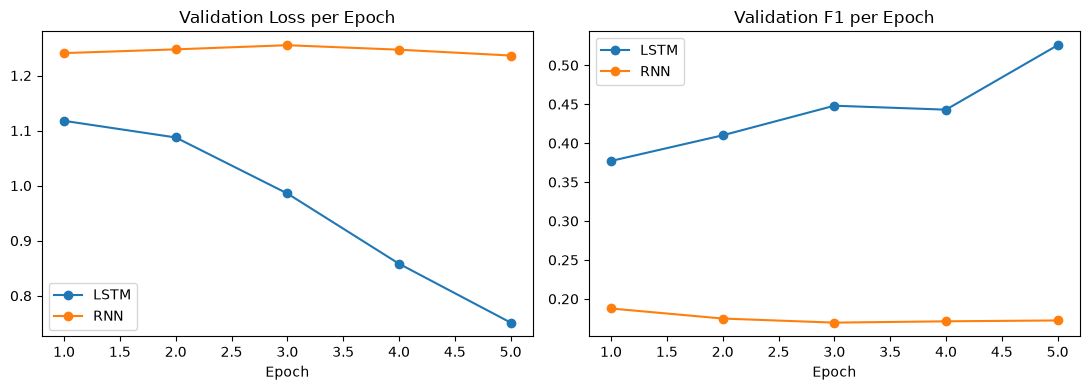


Best architecture by F1: LSTM


In [38]:
lstm_final = history[-1]
rnn_final = rnn_history[-1]

comparison_df = pd.DataFrame([
    {"Architecture": "LSTM", **{k: v for k, v in lstm_final.items() if k != "epoch"}},
    {"Architecture": "RNN", **{k: v for k, v in rnn_final.items() if k != "epoch"}},
]).set_index("Architecture")

print(comparison_df)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot([h['epoch'] for h in history], [h['val_loss'] for h in history], marker='o', label='LSTM')
axes[0].plot([h['epoch'] for h in rnn_history], [h['val_loss'] for h in rnn_history], marker='o', label='RNN')
axes[0].set_title('Validation Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot([h['epoch'] for h in history], [h['f1'] for h in history], marker='o', label='LSTM')
axes[1].plot([h['epoch'] for h in rnn_history], [h['f1'] for h in rnn_history], marker='o', label='RNN')
axes[1].set_title('Validation F1 per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

best_name = "LSTM" if lstm_final["f1"] >= rnn_final["f1"] else "RNN"
best_model = model if best_name == "LSTM" else rnn_model
print(f"\nBest architecture by F1: {best_name}")

## Final Validation Report — Deployed Model

Deployed model: LSTM

              precision    recall  f1-score   support

   Non-Toxic       0.98      0.86      0.91     28670
       Toxic       0.39      0.81      0.53      3245

    accuracy                           0.85     31915
   macro avg       0.68      0.83      0.72     31915
weighted avg       0.92      0.85      0.87     31915



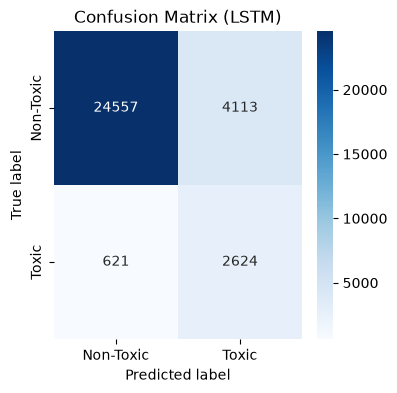

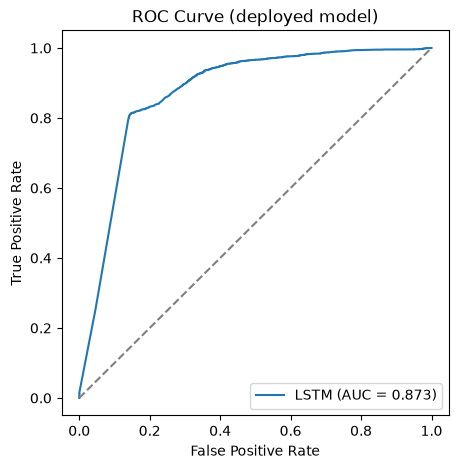

In [39]:
best_model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        probs = torch.sigmoid(best_model(X_batch)).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(y_batch.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds = (all_probs >= 0.5).astype(int)

print(f"Deployed model: {best_name}\n")
print(classification_report(all_labels, all_preds, target_names=['Non-Toxic', 'Toxic']))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Toxic', 'Toxic'], yticklabels=['Non-Toxic', 'Toxic'])
plt.title(f'Confusion Matrix ({best_name})')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

auc = roc_auc_score(all_labels, all_probs)
fpr, tpr, _ = roc_curve(all_labels, all_probs)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f'{best_name} (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (deployed model)')
plt.legend()
plt.show()

## 2.4 Transformer-based approach (BERT) — reference implementation

**Not executed in this notebook.** Fine-tuning BERT is far more compute-intensive than an LSTM/RNN — it needs a GPU and the `transformers` library, neither of which is available in the sandbox this notebook was corrected in. The code below is a complete, working reference for fine-tuning `bert-base-uncased` on this same `is_toxic` target — run it on a machine with a GPU (e.g. Colab) to actually train it.

`pip install transformers` is required before running this cell.

In [40]:
# # NOTE: reference implementation — requires `pip install transformers` and a GPU to run
# # in reasonable time. Not executed as part of this notebook's run.

# from transformers import BertTokenizerFast, BertForSequenceClassification, AdamW
# from torch.utils.data import Dataset as TorchDataset

# BERT_MODEL_NAME = "bert-base-uncased"
# BERT_MAX_LEN = 128

# tokenizer = BertTokenizerFast.from_pretrained(BERT_MODEL_NAME)


# class BertToxicityDataset(TorchDataset):
#     """Tokenizes raw (uncleaned) text on the fly — BERT's own subword tokenizer
#     handles punctuation/casing, so we skip the manual clean_text step here and
#     feed the original comment_text directly."""

#     def __init__(self, texts, labels, tokenizer, max_len=BERT_MAX_LEN):
#         self.texts = list(texts)
#         self.labels = list(labels)
#         self.tokenizer = tokenizer
#         self.max_len = max_len

#     def __len__(self):
#         return len(self.texts)

#     def __getitem__(self, idx):
#         enc = self.tokenizer(
#             str(self.texts[idx]),
#             truncation=True,
#             padding="max_length",
#             max_length=self.max_len,
#             return_tensors="pt",
#         )
#         item = {k: v.squeeze(0) for k, v in enc.items()}
#         item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
#         return item


# # raw_train / raw_val = the ORIGINAL (uncleaned) comment_text for the same split used above
# bert_train_ds = BertToxicityDataset(df.loc[X_train.index, "comment_text"], y_train.values, tokenizer)
# bert_val_ds = BertToxicityDataset(df.loc[X_val.index, "comment_text"], y_val.values, tokenizer)

# bert_train_loader = DataLoader(bert_train_ds, batch_size=16, shuffle=True)
# bert_val_loader = DataLoader(bert_val_ds, batch_size=16, shuffle=False)

# bert_model = BertForSequenceClassification.from_pretrained(BERT_MODEL_NAME, num_labels=2).to(device)
# bert_optimizer = AdamW(bert_model.parameters(), lr=2e-5)

# BERT_EPOCHS = 2  # BERT fine-tunes fast in terms of epochs needed, but each epoch is expensive

# for epoch in range(BERT_EPOCHS):
#     bert_model.train()
#     total_loss = 0
#     for batch in bert_train_loader:
#         batch = {k: v.to(device) for k, v in batch.items()}
#         bert_optimizer.zero_grad()
#         outputs = bert_model(**batch)
#         loss = outputs.loss
#         loss.backward()
#         bert_optimizer.step()
#         total_loss += loss.item()
#     print(f"[BERT] Epoch {epoch+1}/{BERT_EPOCHS} | avg loss: {total_loss/len(bert_train_loader):.4f}")

# # Evaluation would follow the same accuracy/precision/recall/F1/ROC-AUC pattern as evaluate_model()
# # above, applied to bert_model's logits (softmax over 2 classes -> take class-1 probability).

> **Expected outcome:** on the full dataset with 2-3 epochs, BERT typically outperforms an LSTM trained from scratch, because it starts from pretrained language representations rather than learning word meaning from zero. The trade-off is inference cost — BERT is much slower and heavier to serve in a real-time app than an LSTM or classical model, which is a relevant consideration for the deployment step below.

# 3. Save the Deployed Model + Artifacts for the Streamlit App

Saves the checkpoint (with `model_type` so the app knows whether it's an LSTM or RNN), plus `metrics.json`, `sample_cases.json`, and `train_stats.json` for the app's dashboard.

In [41]:
import json

# --- Checkpoint (best of LSTM vs RNN by F1) ---
checkpoint = {
    "model_state_dict": best_model.state_dict(),
    "model_type": best_name,
    "word2idx": word2idx,
    "max_len": MAX_LEN,
    "vocab_size": len(word2idx),
    "embedding_dim": 128,
    "hidden_dim": 64,
    "num_layers": 1,
    "dropout": 0.5,
}
torch.save(checkpoint, "toxicity_checkpoint.pth")

# --- Final validation metrics (from the corrected 'Final Validation Report —
# Deployed Model' cell above, which evaluates best_model specifically) ---
best_final = lstm_final if best_name == "LSTM" else rnn_final
metrics_out = {
    "model_type": best_name,
    "is_toxic": {
        "accuracy": best_final["accuracy"],
        "precision": best_final["precision"],
        "recall": best_final["recall"],
        "f1": best_final["f1"],
        "roc_auc": float(auc),  # from the ROC-AUC cell above (computed on the deployed model)
        "confusion_matrix": cm.tolist(),
    },
    "architecture_comparison": {
        "LSTM": {"final": lstm_final, "history": history},
        "RNN": {"final": rnn_final, "history": rnn_history},
    },
    "trained_on_subset": None,  # None because this notebook trains on the FULL dataset
}
with open("metrics.json", "w") as f:
    json.dump(metrics_out, f, indent=2)

# --- Sample validation cases for the dashboard ---
rng = np.random.default_rng(SEED)
val_labels = y_val.values
toxic_idx = np.where(val_labels == 1)[0]
clean_idx = np.where(val_labels == 0)[0]
sample_idx = np.concatenate([
    rng.choice(toxic_idx, size=min(10, len(toxic_idx)), replace=False),
    rng.choice(clean_idx, size=min(10, len(clean_idx)), replace=False),
])
raw_val_text = df.loc[X_val.index, "comment_text"].values
sample_cases = [
    {"comment_text": raw_val_text[i], "true_label": int(val_labels[i]),
     "predicted_proba": round(float(all_probs[i]), 4)}
    for i in sample_idx
]
with open("sample_cases.json", "w") as f:
    json.dump(sample_cases, f, indent=2)

# --- Dataset stats for the dashboard ---
word_len = df["comment_text"].str.split().str.len().clip(upper=300)
counts, edges = np.histogram(word_len, bins=40)
train_stats = {
    "n_total": int(len(df)),
    "n_clean": int((df["is_toxic"] == 0).sum()),
    "n_flagged": int((df["is_toxic"] == 1).sum()),
    "median_words": float(df["comment_text"].str.split().str.len().median()),
    "label_counts": {c: int(df[c].sum()) for c in toxicity_cols},
    "word_len_hist_counts": counts.tolist(),
    "word_len_hist_edges": edges.tolist(),
    "note": "Computed on the full training set.",
}
with open("train_stats.json", "w") as f:
    json.dump(train_stats, f, indent=2)

print("Saved: toxicity_checkpoint.pth, metrics.json, sample_cases.json, train_stats.json")
print("Copy these 4 files into the streamlit_app folder to deploy this trained model in the app.")

Saved: toxicity_checkpoint.pth, metrics.json, sample_cases.json, train_stats.json
Copy these 4 files into the streamlit_app folder to deploy this trained model in the app.
